# 08 — Robustness checks on the widened latent-regression model of turnout

Notebook 07 fit PLS on a **70-variable, 14-family curated predictor pool** (dynamically read from `predictor_metadata.csv`) and selected **4 components**, train R^2 = 0.661, CV R^2 = 0.586 — a substantial widening from the earlier 14-variable "meeting PLS" model. This notebook re-runs and extends the robustness-check suite against that wider model. Three checks carry over directly from the previous (14-variable) version of this notebook, now re-run on the 70-variable set; five are new:

1. **sklearn cross-check (new, done first).** A cheap correctness gate: does an off-the-shelf `sklearn.cross_decomposition.PLSRegression` agree with the hand-rolled NIPALS implementation now that it's handling 70 predictors instead of 14? This is a plumbing check, not a finding about turnout.
2. **Spatially blocked cross-validation (carried over, widened, extended).** PLS vs. two PCA-based baselines vs. elastic net, holding out whole geographic regions instead of random CTs — now with **four** methods instead of three (the previous "supervised PCA" baseline was mislabeled; it's renamed **PCR** below, and a true supervised-PCA baseline is added alongside it), plus a **block-count sensitivity check** (5 vs. 10 spatial blocks).
3. **Per-election refit (carried over, widened).** Same structure as before — refit against municipal/provincial/federal turnout separately — now on the 70-variable set.
4. **Prior-round-vs-current component comparison (new — the centerpiece).** Does broadening the predictor pool from 14 to 70 variables change the earlier dominant latent axis, or just describe the same axis with more variables? Compared via the correlation of each model's leading-component *scores* across CTs, since the two models have different numbers of predictors and their loading vectors aren't directly comparable entry-by-entry.
5. **Alternative-subset checks (new).** Refit on the 70-variable set minus the `transportation` family, and compare its leading component to the full current model's.
6. **Sparse PLS (new, standalone).** A variable-selection-stability companion to VIP: which predictors survive soft-thresholding inside each retained component, at a shrinkage parameter tuned by inner cross-validation.
7. **Bootstrap stability (carried over, extended).** Same 300-draw spatial-block bootstrap as before, now also tracking how often each predictor survives sparse-PLS thresholding across draws.

Every section ends with a plain-language verdict, and the text is explicit throughout about which parts are a genuinely new finding about turnout versus an internal consistency/plumbing check.

In [1]:
from __future__ import annotations

import math
import re
from dataclasses import dataclass
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.linear_model import ElasticNetCV
from tqdm.notebook import tqdm

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 140)

In [2]:
# --- Paths -----------------------------------------------------------------
REPO_ROOT = Path.cwd().resolve().parents[1]
FEATURES_ROOT = REPO_ROOT / "data/toronto_election_turnout/features"
INPUT_PATH = FEATURES_ROOT / "ct_model_input.csv"
METADATA_PATH = FEATURES_ROOT / "predictor_metadata.csv"
GEOMETRY_PATH = FEATURES_ROOT / "ct_model_input.geojson"
OUTPUT_ROOT = REPO_ROOT / "data/toronto_election_turnout/model"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# --- Target ------------------------------------------------------------------
TARGET = "mean_turnout"

# --- Predictor list, read dynamically from notebook 06's curated metadata ---
# Same dynamic-loading pattern as notebook 07: everything with family != "excluded"
# is the curated pool, so this notebook can't silently drift out of sync with
# notebook 06/07 if the curation is revised.
predictor_metadata = pd.read_csv(METADATA_PATH)
predictor_metadata_active = predictor_metadata[predictor_metadata["family"] != "excluded"].copy()

PREDICTORS = predictor_metadata_active["variable"].tolist()
FAMILIES = {
    family: group["variable"].tolist()
    for family, group in predictor_metadata_active.groupby("family", sort=False)
}
VARIABLE_FAMILY = dict(zip(predictor_metadata_active["variable"], predictor_metadata_active["family"]))

print(f"{len(PREDICTORS)} predictors across {len(FAMILIES)} families (read from {METADATA_PATH.name}):")
for family, variables in FAMILIES.items():
    print(f"  {family:38s} {len(variables):2d}")

# --- The prior-round 14-variable "meeting PLS" shortlist, kept hardcoded for ---
# comparison purposes only (Check 3 below). Of these, citizen-adult share is
# excluded from this round's approved PREDICTORS list above (citizenship
# composition is instead represented via block3_non_citizen_share), but it is
# still present as a raw column in ct_model_input.csv, so this list still
# works standalone. (TTS no-car-household share, previously also excluded
# here, is now part of PREDICTORS itself, in the transportation family.)
# `block1_age_18_34_share` no longer exists upstream -- this round's age
# breakdown splits it into block1_age_18_29_share / block1_age_30_64_share.
# We substitute block1_age_18_29_share, the closer analogue to the original
# "young adult" concept, so the list stays at its original 14 variables.
ORIGINAL_PREDICTORS = [
    "block1_age_18_29_share", "block1_age_65_plus_share", "block1_average_household_size",
    "block1_bachelors_or_higher_25_64_share", "block1_low_income_lim_at_share", "block2_renter_share",
    "block2_same_address_5yr_share", "block2_apartment_share", "block2_condo_share",
    "block2_population_density_per_km2", "block3_citizen_adult_share", "block3_immigrant_share",
    "block3_visible_minority_share", "block5_tts_no_car_household_share",
]

# The three election-level outcome variants checked in section 3, alongside
# TARGET (the three-election mean), all already present in ct_model_input.csv.
LEVEL_OUTCOMES = {
    "municipal": "municipal_turnout",
    "provincial": "provincial_turnout",
    "federal": "federal_turnout",
}

# --- Cosmetic lookups (plain names / family labels), same convention as nb 07 ---
PLAIN_NAME_OVERRIDES = {
    "block1_occ_management_share": "management occupation share",
    "block1_occ_sales_service_share": "sales and service occupation share",
    "block1_occ_trades_transport_share": "trades and transport occupation share",
    "block1_occ_manufacturing_share": "manufacturing occupation share",
    "block5_tts_vehicles_per_household": "TTS vehicles per household",
    "block5_tts_transit_trip_share": "TTS transit trip share",
    "block5_tts_auto_trip_share": "TTS auto trip share",
    "block5_tts_walk_or_bike_trip_share": "TTS walk or bike trip share",
    "block5_tts_avg_trip_distance_km": "TTS average trip distance (km)",
    "block5_tts_trips_per_person": "TTS trips per person",
    "block5_census_long_commute_60min_share": "long commute (60+ minutes) share",
    "block5_census_work_from_home_share": "work from home share",
    "block5_distance_city_hall_km": "distance to city hall (km)",
    "block5_transit_proximity_index": "transit proximity index",
    "block5_grocery_proximity_index": "grocery proximity index",
    "block5_parks_proximity_index": "park proximity index",
    "block5_childcare_proximity_index": "childcare proximity index",
    "block2_dwelling_vintage_pre1960_share": "dwellings built before 1960 share",
    "block2_core_housing_need_share": "core housing need share",
    "block2_dwelling_major_repairs_needed_share": "dwelling needs major repairs share",
    "block3_citizen_adult_share": "citizen adult share",
    "block5_tts_no_car_household_share": "TTS no car household share",
}


def plain_name(variable: str) -> str:
    if variable in PLAIN_NAME_OVERRIDES:
        return PLAIN_NAME_OVERRIDES[variable]
    return re.sub(r"^block\d+_", "", variable).replace("_", " ")


def variable_family(variable: str) -> str:
    return VARIABLE_FAMILY.get(variable, "other")


def family_label(family: str) -> str:
    return family.replace("_", " ")


FAMILY_COLORS = {
    "age_life_stage": "#2a78d6",
    "household_family": "#eb6834",
    "education": "#1baf7a",
    "labour_market": "#5b8c5a",
    "occupation": "#2e8b57",
    "income_class": "#eda100",
    "housing_tenure_stability": "#e87ba4",
    "housing_form": "#c2185b",
    "housing_affordability_need": "#f06292",
    "immigration_citizenship": "#008300",
    "culture_language": "#66bb6a",
    "transportation": "#4a3aa7",
    "urban_form": "#7b5e9a",
    "accessibility": "#e34948",
}

# --- Shuffled-CV parameters (shared convention with notebook 07) ---
CV_FOLDS = 10
RANDOM_SEED = 20260803
MAX_COMPONENTS = 12  # matches notebook 07's component-count search cap

# --- Robustness-check parameters ---
N_SPATIAL_BLOCKS = 5               # primary spatial-CV blocking, same scheme as before
N_SPATIAL_BLOCKS_SENSITIVITY = 10  # new: sensitivity check on blocking granularity
SPATIAL_SEED = 20260818
INNER_MAX_COMPONENTS = 6           # component-count search range inside each outer spatial fold
LEVEL_MAX_COMPONENTS = 12          # per-election PLS component cap (matches MAX_COMPONENTS)
N_BOOTSTRAP = 300                  # spatial-block bootstrap draws

# New grids for the two hand-rolled methods that need their own inner tuning.
SUPERVISED_PCA_CORR_GRID = [0.10, 0.15, 0.20, 0.25, 0.30]
SPARSE_LAM_GRID = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]

70 predictors across 14 families (read from predictor_metadata.csv):
  age_life_stage                          4
  household_family                        6
  education                               3
  income_class                            2
  labour_market                           5
  occupation                              8
  housing_tenure_stability                3
  housing_form                            6
  housing_affordability_need              4
  immigration_citizenship                 5
  culture_language                        4
  transportation                          9
  urban_form                              2
  accessibility                           9


## Load the model-input table

Same 585-CT table notebook 07 used. We rebuild the headline PLS model here too (fresh `fit_pls`/`choose_components` calls, not a saved object) so this notebook is self-contained and can be run on its own.

In [3]:
df = pd.read_csv(INPUT_PATH)
print(f"Loaded {len(df)} CTs, {df.shape[1]} columns from {INPUT_PATH.relative_to(REPO_ROOT)}")

missing = [v for v in PREDICTORS if v not in df.columns]
if missing:
    raise ValueError(f"Missing predictors in ct_model_input.csv: {missing}")
missing_orig = [v for v in ORIGINAL_PREDICTORS if v not in df.columns]
if missing_orig:
    raise ValueError(f"Missing original predictors in ct_model_input.csv: {missing_orig}")
if TARGET not in df.columns:
    raise ValueError(f"Missing target column: {TARGET}")
missing_levels = [c for c in LEVEL_OUTCOMES.values() if c not in df.columns]
if missing_levels:
    raise ValueError(f"Missing level-outcome columns: {missing_levels}")

x_all = df[PREDICTORS].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
y_all = pd.to_numeric(df[TARGET], errors="coerce").to_numpy(dtype=float)
keep = np.isfinite(y_all) & np.isfinite(x_all).all(axis=1)
print(f"{keep.sum()} of {len(df)} CTs have complete data on all {len(PREDICTORS)} widened predictors + target")

x = x_all[keep]
y = y_all[keep]
df_model = df.loc[keep].reset_index(drop=True)

Loaded 585 CTs, 204 columns from data/toronto_election_turnout/features/ct_model_input.csv
585 of 585 CTs have complete data on all 70 widened predictors + target


## The PLS algorithm, reused from notebook 07

`PlsModel`, `standardize_train`, `fit_pls`, `predict_pls`, `metrics`, `cv_predictions`, and `choose_components` are copied verbatim from notebook 07 (and from the previous version of this notebook) so results stay numerically comparable and this notebook doesn't depend on notebook 07 having been run first. `cv_predictions`/`choose_components` keep the optional `seed`/`folds` arguments (notebook 07's copies hardcode the module-level constants instead) so the same code also drives the lighter inner-fold component selection used inside the spatial-CV loop further down.

In [4]:
@dataclass
class PlsModel:
    x_mean: np.ndarray
    x_std: np.ndarray
    y_mean: float
    y_std: float
    weights: np.ndarray
    loadings: np.ndarray
    q: np.ndarray
    scores: np.ndarray
    coef_scaled: np.ndarray
    vip: np.ndarray


def standardize_train(x: np.ndarray, y: np.ndarray):
    x_mean = np.nanmean(x, axis=0)
    x_std = np.nanstd(x, axis=0, ddof=0)
    x_std[x_std == 0] = 1
    y_mean = float(np.nanmean(y))
    y_std = float(np.nanstd(y, ddof=0)) or 1.0
    return (x - x_mean) / x_std, (y - y_mean) / y_std, x_mean, x_std, y_mean, y_std


def fit_pls(x: np.ndarray, y: np.ndarray, n_components: int) -> PlsModel:
    xs, ys, x_mean, x_std, y_mean, y_std = standardize_train(x, y)
    x_def = xs.copy()
    y_def = ys.copy()
    n, p = xs.shape
    comps = min(n_components, p, n - 1)
    weights = np.zeros((p, comps))
    loadings = np.zeros((p, comps))
    q = np.zeros(comps)
    scores = np.zeros((n, comps))
    ssy = np.zeros(comps)
    for comp in range(comps):
        w = x_def.T @ y_def
        norm = np.linalg.norm(w)
        if norm < 1e-12:
            weights, loadings, q, scores, ssy = weights[:, :comp], loadings[:, :comp], q[:comp], scores[:, :comp], ssy[:comp]
            break
        w = w / norm
        t = x_def @ w
        tt = float(t.T @ t)
        if tt < 1e-12:
            break
        p_load = (x_def.T @ t) / tt
        q_load = float((y_def.T @ t) / tt)
        x_def = x_def - np.outer(t, p_load)
        y_def = y_def - q_load * t
        weights[:, comp] = w
        loadings[:, comp] = p_load
        q[comp] = q_load
        scores[:, comp] = t
        ssy[comp] = (q_load**2) * tt

    if weights.shape[1] == 0:
        coef_scaled = np.zeros(p)
        vip = np.zeros(p)
    else:
        w_star = weights @ np.linalg.pinv(loadings.T @ weights)
        coef_scaled = w_star @ q
        total_ssy = float(ssy.sum()) or 1.0
        vip = np.sqrt(p * ((weights**2) @ ssy) / total_ssy)
    return PlsModel(x_mean, x_std, y_mean, y_std, weights, loadings, q, scores, coef_scaled, vip)


def predict_pls(model: PlsModel, x: np.ndarray) -> np.ndarray:
    xs = (x - model.x_mean) / model.x_std
    return (xs @ model.coef_scaled) * model.y_std + model.y_mean


def metrics(y: np.ndarray, pred: np.ndarray, k: int) -> dict[str, float]:
    resid = y - pred
    sse = float(np.sum(resid**2))
    sst = float(np.sum((y - np.mean(y)) ** 2))
    r2 = 1 - sse / sst if sst else 0.0
    n = len(y)
    adj = 1 - (1 - r2) * (n - 1) / max(n - k - 1, 1)
    rmse = math.sqrt(sse / n)
    return {"r2": r2, "adjusted_r2": adj, "rmse": rmse}


def cv_predictions(x: np.ndarray, y: np.ndarray, n_components: int, seed: int = RANDOM_SEED, folds: int = CV_FOLDS) -> np.ndarray:
    rng = np.random.default_rng(seed)
    indices = np.arange(len(y))
    rng.shuffle(indices)
    fold_idx = np.array_split(indices, folds)
    pred = np.zeros_like(y, dtype=float)
    for fold in fold_idx:
        train = np.setdiff1d(indices, fold, assume_unique=False)
        model = fit_pls(x[train], y[train], n_components)
        pred[fold] = predict_pls(model, x[fold])
    return pred


def choose_components(x: np.ndarray, y: np.ndarray, max_components: int, seed: int = RANDOM_SEED, folds: int = CV_FOLDS):
    rows = []
    max_comps = min(max_components, x.shape[1], x.shape[0] - 2)
    for comp in range(1, max_comps + 1):
        cv_pred = cv_predictions(x, y, comp, seed=seed, folds=folds)
        cv = metrics(y, cv_pred, comp)
        rows.append({"n_components": comp, "cv_r2": cv["r2"], "cv_rmse": cv["rmse"]})
    grid = pd.DataFrame(rows)
    best = int(grid.sort_values(["cv_rmse", "n_components"]).iloc[0]["n_components"])
    return best, grid


best_n_components, mean_component_grid = choose_components(x, y, max_components=MAX_COMPONENTS)
mean_model = fit_pls(x, y, best_n_components)
mean_cv_pred = cv_predictions(x, y, best_n_components)
mean_cv_fit = metrics(y, mean_cv_pred, best_n_components)
mean_train_fit = metrics(y, predict_pls(mean_model, x), best_n_components)
print(
    f"Widened mean-turnout model: {best_n_components} component(s), "
    f"train R^2 = {mean_train_fit['r2']:.3f}, CV R^2 = {mean_cv_fit['r2']:.3f} "
    f"(notebook 07 reported 4 components, train R^2 0.661, CV R^2 0.586)"
)

Widened mean-turnout model: 4 component(s), train R^2 = 0.661, CV R^2 = 0.586 (notebook 07 reported 4 components, train R^2 0.661, CV R^2 0.586)


## Check 0 — sklearn cross-check (plumbing, not a finding)

Before running anything heavier, a cheap correctness gate on the hand-rolled NIPALS implementation itself: widening from 14 to 70 predictors is exactly the kind of change that could expose a numerical bug that a small predictor set never triggered (rank issues, a tighter near-zero-norm cutoff, etc). We fit `sklearn.cross_decomposition.PLSRegression` with the **same component count notebook 07 selected** on the same raw `x`/`y` (it does its own internal standardization, so there's no need to feed it pre-scaled data) and compare its predicted values on the full sample against `predict_pls(mean_model, x)`. If the hand-rolled implementation is still correct, the two should agree up to floating-point noise — PLS1 has a unique solution for a given component count, so there's no reason for a *correct* implementation to disagree with sklearn's, regardless of predictor count.

In [5]:
skl_pls = PLSRegression(n_components=best_n_components, scale=True)
skl_pls.fit(x, y.reshape(-1, 1))
skl_pred = skl_pls.predict(x).ravel()
hand_pred = predict_pls(mean_model, x)

cross_check_corr = float(np.corrcoef(hand_pred, skl_pred)[0, 1])
cross_check_max_diff = float(np.max(np.abs(hand_pred - skl_pred)))
cross_check_status = "PASS" if cross_check_corr > 0.999 and cross_check_max_diff < 1e-6 else "FAIL"

print(f"sklearn PLSRegression vs. hand-rolled NIPALS, {best_n_components}-component fit on all {len(PREDICTORS)} predictors:")
print(f"  correlation between predicted values on the full sample: {cross_check_corr:.10f}")
print(f"  max |prediction difference|: {cross_check_max_diff:.3e}")
print(f"  STATUS: {cross_check_status}")

sklearn PLSRegression vs. hand-rolled NIPALS, 4-component fit on all 70 predictors:
  correlation between predicted values on the full sample: 1.0000000000
  max |prediction difference|: 1.110e-16
  STATUS: PASS


**Verdict.** A `PASS` here means the hand-rolled NIPALS implementation agrees with sklearn's reference PLS implementation to within floating-point noise even at 70 predictors — the widening exercise in notebook 07 did not quietly introduce a numerical bug. A `FAIL` would mean the gap is a real disagreement, not just floating-point noise, and everything downstream in this notebook (which all reuses `fit_pls`) would need to be treated with real suspicion until it's resolved.

## Check 1 — does the story hold if we cross-validate by geography instead of randomly, and how sensitive is that to the exact blocking?

Nearby CTs tend to share housing markets, built form, and demographics, so a randomly shuffled CV fold can let a training CT "leak" local information about a nearly identical, physically adjacent test CT — making CV performance look better than it would in genuinely unseen geography. Spatially blocked CV holds out whole geographic regions instead.

**Method:**
1. Compute each CT's centroid (from `ct_model_input.geojson`, projected to EPSG:3347) and cluster them into compact geographic blocks with k-means — `N_SPATIAL_BLOCKS = 5` as before, plus `N_SPATIAL_BLOCKS_SENSITIVITY = 10` as a new granularity-sensitivity check.
2. Treat each block as one outer CV fold: hold it out entirely, train on the rest, predict the held-out block.
3. Inside each outer training fold, tune each method's hyperparameter(s) with a lighter *shuffled* 5-fold inner CV on that fold's training data only — this never touches the held-out block.
4. Compare **four** methods on the widened 70-predictor set:
   - **PLS** — the same hand-rolled NIPALS model used throughout this notebook.
   - **PCR (principal component regression)** — standardize, PCA the predictors, OLS of turnout on *all* the PCA scores. This is what the previous version of this notebook called "supervised PCA," which was a mislabeling: the PCA step never looks at turnout, so there is nothing supervised about it. Renamed here to PCR, which is what it actually is.
   - **Supervised PCA (true, new)** — the Bair et al. (2006) procedure: first screen predictors to those whose training-fold correlation with turnout exceeds a threshold, *then* PCA just that screened subset, then OLS on the resulting scores. `train_y` is used twice here (screening and the final OLS), which is what makes this version actually "supervised."
   - **Elastic net** — `sklearn.ElasticNetCV`, tuning its own alpha/l1-ratio by internal CV.
5. Pool each outer scheme's held-out predictions and compute one overall R^2/RMSE/MAE per method, for the 5-block and 10-block schemes side by side.

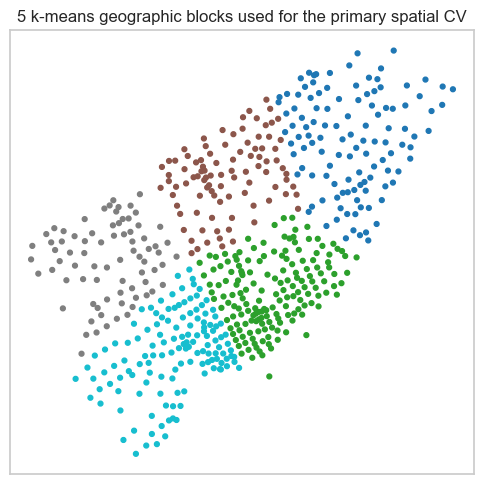

,CTs
spatial_block_5,
1,116
2,165
3,94
4,77
5,133


In [6]:
ct_geo = gpd.read_file(GEOMETRY_PATH)[["ct_id", "geometry"]].to_crs(3347)
ct_geo["x"] = ct_geo.geometry.centroid.x
ct_geo["y"] = ct_geo.geometry.centroid.y

geo = df_model[["ct_id"]].merge(ct_geo[["ct_id", "x", "y"]], on="ct_id", how="left")
if geo[["x", "y"]].isna().any().any():
    raise ValueError("Some CTs are missing geometry -- cannot build spatial blocks")

coords = geo[["x", "y"]].to_numpy(float)
df_model = df_model.assign(
    spatial_block_5=KMeans(n_clusters=N_SPATIAL_BLOCKS, random_state=SPATIAL_SEED, n_init=50).fit_predict(coords) + 1,
    spatial_block_10=KMeans(n_clusters=N_SPATIAL_BLOCKS_SENSITIVITY, random_state=SPATIAL_SEED, n_init=50).fit_predict(coords) + 1,
)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(geo["x"], geo["y"], c=df_model["spatial_block_5"], cmap="tab10", s=12)
ax.set_title(f"{N_SPATIAL_BLOCKS} k-means geographic blocks used for the primary spatial CV")
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

df_model.groupby("spatial_block_5").size().rename("CTs").to_frame()

### The four methods and the inner-tuning machinery

In [7]:
def standardize_fit(train_x: np.ndarray):
    mean = train_x.mean(axis=0)
    std = train_x.std(axis=0)
    std[std == 0] = 1
    return mean, std


def pcr_predict(train_x, train_y, test_x, n_components):
    '''Principal component regression: standardize, PCA the predictors
    (unsupervised -- the PCA step never sees train_y), then OLS of y on the
    resulting scores. This is the function the previous version of this
    notebook called "supervised PCA" -- that was a mislabeling, since y is
    never used to pick which predictors or components to keep, only in the
    final OLS step. The true supervised-PCA baseline is `supervised_pca_predict`
    below.'''
    x_mean, x_std = standardize_fit(train_x)
    train_z = (train_x - x_mean) / x_std
    test_z = (test_x - x_mean) / x_std
    pca = PCA(n_components=n_components, random_state=0)
    train_scores = pca.fit_transform(train_z)
    test_scores = pca.transform(test_z)
    design = np.column_stack([np.ones(len(train_scores)), train_scores])
    beta = np.linalg.lstsq(design, train_y, rcond=None)[0]
    test_design = np.column_stack([np.ones(len(test_scores)), test_scores])
    return test_design @ beta


def supervised_pca_predict(train_x, train_y, test_x, corr_threshold, n_components):
    '''True supervised-PCA baseline (Bair et al. 2006): screen predictors to
    those whose |corr(x_j, train_y)| on the training fold exceeds
    corr_threshold, PCA just that screened subset, then OLS of y on the
    resulting scores. Unlike pcr_predict, train_y is used twice -- once to
    screen predictors, once in the final OLS -- which is what makes this one
    actually supervised. If a threshold screens out every predictor (possible
    at the stricter end of the grid on a small training fold) we fall back to
    including all predictors, rather than crashing on an empty screened set;
    this fallback is intentional and documented here, not silent.'''
    x_mean, x_std = standardize_fit(train_x)
    train_z = (train_x - x_mean) / x_std
    test_z = (test_x - x_mean) / x_std
    corrs = np.array([np.corrcoef(train_z[:, j], train_y)[0, 1] for j in range(train_z.shape[1])])
    corrs = np.nan_to_num(corrs, nan=0.0)
    mask = np.abs(corrs) > corr_threshold
    if not mask.any():
        mask = np.ones(train_z.shape[1], dtype=bool)  # fallback: threshold screened out everything
    train_screened = train_z[:, mask]
    test_screened = test_z[:, mask]
    k = min(n_components, train_screened.shape[1])
    pca = PCA(n_components=k, random_state=0)
    train_scores = pca.fit_transform(train_screened)
    test_scores = pca.transform(test_screened)
    design = np.column_stack([np.ones(len(train_scores)), train_scores])
    beta = np.linalg.lstsq(design, train_y, rcond=None)[0]
    test_design = np.column_stack([np.ones(len(test_scores)), test_scores])
    return test_design @ beta


def elastic_net_predict(train_x, train_y, test_x):
    '''Elastic-net baseline. alpha/l1_ratio are tuned by ElasticNetCV's own
    internal 5-fold CV on the training fold only.'''
    x_mean, x_std = standardize_fit(train_x)
    y_mean = train_y.mean()
    y_std = train_y.std() or 1.0
    enet = ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
        alphas=np.logspace(-3, 0, 25),
        cv=5,
        random_state=SPATIAL_SEED,
        max_iter=10000,
    )
    enet.fit((train_x - x_mean) / x_std, (train_y - y_mean) / y_std)
    return enet.predict((test_x - x_mean) / x_std) * y_std + y_mean


def shuffled_cv_predict(x, y, fit_predict, seed, folds=5):
    '''Generic k-fold predictor used only to tune a hyperparameter inside
    each outer spatial-training fold -- it never sees the held-out block.'''
    rng = np.random.default_rng(seed)
    indices = np.arange(len(y))
    rng.shuffle(indices)
    fold_idx = np.array_split(indices, folds)
    pred = np.zeros(len(y))
    for fold in fold_idx:
        train = np.setdiff1d(indices, fold)
        pred[fold] = fit_predict(x[train], y[train], x[fold])
    return pred


def choose_components_inner(x, y, fit_predict_factory, max_components, seed):
    best = None
    for k in range(1, max_components + 1):
        pred = shuffled_cv_predict(x, y, fit_predict_factory(k), seed=seed, folds=5)
        rmse = metrics(y, pred, k)["rmse"]
        if best is None or rmse < best[0]:
            best = (rmse, k)
    return best[1]


def choose_supervised_pca_inner(x, y, corr_grid, max_components, seed):
    '''Grid-search corr_threshold x n_components jointly, minimizing inner-CV
    RMSE -- supervised PCA has two hyperparameters instead of PLS/PCR's one.'''
    best = None
    for corr_threshold in corr_grid:
        for k in range(1, max_components + 1):
            pred = shuffled_cv_predict(
                x, y,
                lambda tx, ty, sx, c=corr_threshold, k=k: supervised_pca_predict(tx, ty, sx, c, k),
                seed=seed, folds=5,
            )
            rmse = metrics(y, pred, k)["rmse"]
            if best is None or rmse < best[0]:
                best = (rmse, corr_threshold, k)
    return best[1], best[2]


def pool_metrics(y: np.ndarray, pred: np.ndarray) -> dict[str, float]:
    resid = y - pred
    sst = float(np.sum((y - y.mean()) ** 2))
    return {
        "r2": 1 - float(resid @ resid) / sst,
        "rmse": math.sqrt(float(np.mean(resid**2))),
        "mae": float(np.mean(np.abs(resid))),
    }

In [8]:
def run_spatial_cv(block_labels: np.ndarray, n_blocks_label: int):
    methods = ["pls", "pcr", "supervised_pca", "elastic_net"]
    predictions = {m: np.zeros(len(y)) for m in methods}
    settings = []

    for block in tqdm(sorted(np.unique(block_labels)), desc=f"Outer spatial folds ({n_blocks_label} blocks)"):
        train_idx = np.where(block_labels != block)[0]
        test_idx = np.where(block_labels == block)[0]
        x_train, y_train = x[train_idx], y[train_idx]
        x_test = x[test_idx]

        pls_k = choose_components_inner(
            x_train, y_train,
            lambda k: (lambda tx, ty, sx: predict_pls(fit_pls(tx, ty, k), sx)),
            INNER_MAX_COMPONENTS, seed=SPATIAL_SEED,
        )
        predictions["pls"][test_idx] = predict_pls(fit_pls(x_train, y_train, pls_k), x_test)

        pcr_k = choose_components_inner(
            x_train, y_train,
            lambda k: (lambda tx, ty, sx: pcr_predict(tx, ty, sx, k)),
            INNER_MAX_COMPONENTS, seed=SPATIAL_SEED,
        )
        predictions["pcr"][test_idx] = pcr_predict(x_train, y_train, x_test, pcr_k)

        spca_threshold, spca_k = choose_supervised_pca_inner(
            x_train, y_train, SUPERVISED_PCA_CORR_GRID, INNER_MAX_COMPONENTS, seed=SPATIAL_SEED,
        )
        predictions["supervised_pca"][test_idx] = supervised_pca_predict(x_train, y_train, x_test, spca_threshold, spca_k)

        predictions["elastic_net"][test_idx] = elastic_net_predict(x_train, y_train, x_test)

        settings.append({
            "n_blocks": n_blocks_label, "block": int(block),
            "pls_components": pls_k, "pcr_components": pcr_k,
            "supervised_pca_corr_threshold": spca_threshold, "supervised_pca_components": spca_k,
        })

    summary = pd.DataFrame(
        [{"method": m, "n_blocks": n_blocks_label, **pool_metrics(y, pred)} for m, pred in predictions.items()]
    )
    return summary, pd.DataFrame(settings)


spatial_summary_5, spatial_settings_5 = run_spatial_cv(df_model["spatial_block_5"].to_numpy(), N_SPATIAL_BLOCKS)
spatial_summary_10, spatial_settings_10 = run_spatial_cv(df_model["spatial_block_10"].to_numpy(), N_SPATIAL_BLOCKS_SENSITIVITY)

spatial_cv_summary = pd.concat([spatial_summary_5, spatial_summary_10], ignore_index=True)
spatial_cv_summary = spatial_cv_summary.sort_values(["n_blocks", "r2"], ascending=[True, False]).reset_index(drop=True)
spatial_cv_summary.to_csv(OUTPUT_ROOT / "robustness_spatial_cv_summary.csv", index=False)

print(f"Shuffled 10-fold CV R^2 (whole-sample convention, 70 predictors): {mean_cv_fit['r2']:.3f}")
print()
spatial_cv_summary

Outer spatial folds (5 blocks):   0%|          | 0/5 [00:00<?, ?it/s]

Outer spatial folds (10 blocks):   0%|          | 0/10 [00:00<?, ?it/s]

Shuffled 10-fold CV R^2 (whole-sample convention, 70 predictors): 0.586



,method,n_blocks,r2,rmse,mae
0,pcr,5,0.494563,0.061799,0.046524
1,elastic_net,5,0.483905,0.062447,0.045367
2,supervised_pca,5,0.472005,0.063163,0.046557
3,pls,5,0.461376,0.063796,0.047861
4,elastic_net,10,0.500824,0.061415,0.044966
5,pls,10,0.470310,0.063264,0.045863
6,supervised_pca,10,0.420841,0.066152,0.048761
7,pcr,10,0.413233,0.066586,0.049132


In [9]:
spatial_cv_pivot = spatial_cv_summary.pivot(index="method", columns="n_blocks", values=["r2", "rmse"])
print("Pooled R^2 / RMSE per method, 5-block vs. 10-block spatial CV, side by side:")
spatial_cv_pivot

Pooled R^2 / RMSE per method, 5-block vs. 10-block spatial CV, side by side:


r2                rmse          
n_blocks              5         10        5         10
method                                                
elastic_net     0.483905  0.500824  0.062447  0.061415
pcr             0.494563  0.413233  0.061799  0.066586
pls             0.461376  0.470310  0.063796  0.063264
supervised_pca  0.472005  0.420841  0.063163  0.066152

In [10]:
print("Inner-tuned hyperparameter settings across outer folds (5-block scheme):")
print(spatial_settings_5.to_string(index=False))
print()
print("Inner-tuned hyperparameter settings across outer folds (10-block scheme):")
print(spatial_settings_10.to_string(index=False))

Inner-tuned hyperparameter settings across outer folds (5-block scheme):
 n_blocks  block  pls_components  pcr_components  supervised_pca_corr_threshold  supervised_pca_components
        5      1               5               6                            0.2                          6
        5      2               4               6                            0.1                          6
        5      3               4               6                            0.1                          6
        5      4               5               6                            0.1                          6
        5      5               4               6                            0.1                          6

Inner-tuned hyperparameter settings across outer folds (10-block scheme):
 n_blocks  block  pls_components  pcr_components  supervised_pca_corr_threshold  supervised_pca_components
       10      1               4               6                           0.10                        

**Verdict.** Compare the table above against the shuffled 10-fold CV R^2 printed just above it: a real but moderate decline under spatial blocking (relative to the shuffled-CV number) is expected, since some of the shuffled-CV performance genuinely comes from nearby CTs resembling each other. Whichever method tops the pooled R^2 column is the one that generalizes best to genuinely unseen geography on the widened predictor set; a `supervised_pca` or `pcr` baseline edging out `pls` here would not undercut the headline PLS model's interpretability story (that's about which variables matter and how, not raw predictive accuracy) but would be worth taking seriously as evidence that the extra flexibility of 70 predictors makes the simpler two-step PCA baselines competitive once geography is held out properly. The 5-block vs. 10-block side-by-side table above is the direct answer to "is this sensitive to the exact blocking granularity": similar rankings and similar R^2 levels across both say the spatial-CV conclusion isn't an artifact of picking exactly 5 blocks; a method's ranking flipping between the two block counts says the opposite. The settings tables above are also worth a glance on their own: a hyperparameter that swings wildly across outer folds (e.g. `pls_components` jumping from 1 to 6) signals tuning instability on a given training fold's size, which is itself a useful caveat on how much to trust that fold's held-out prediction.

## Check 2 — does the story hold per election instead of averaged?

`TARGET` is the *mean* of municipal, provincial, and federal participation. That could be smoothing over real differences between how each election is decided. Here we refit the identical widened 70-predictor PLS approach against each election separately and ask whether the resulting latent axis looks like the same primary story, or something different. As before, we compare each level model's **first component directly** to the mean model's first component (sign-aligned), rather than a general-purpose best-match search across all components — a fair simplification as long as the mean model's first component remains the one that actually correlates with turnout, which the family-VIP and component-correlation tables from notebook 07 confirm it is.

In [11]:
level_specs = {"mean": TARGET, **LEVEL_OUTCOMES}
level_results = {}

for level, target_col in tqdm(level_specs.items(), desc="Per-election refits"):
    y_level_all = pd.to_numeric(df[target_col], errors="coerce").to_numpy(dtype=float)
    keep_level = np.isfinite(y_level_all) & np.isfinite(x_all).all(axis=1)
    xl, yl = x_all[keep_level], y_level_all[keep_level]
    n_comp, _ = choose_components(xl, yl, max_components=LEVEL_MAX_COMPONENTS)
    model = fit_pls(xl, yl, n_comp)
    cv_pred = cv_predictions(xl, yl, n_comp)
    cv_fit = metrics(yl, cv_pred, n_comp)
    level_results[level] = {
        "target": target_col, "n": len(yl), "n_components": n_comp,
        "cv_r2": cv_fit["r2"], "cv_rmse": cv_fit["rmse"], "model": model,
    }

mean_comp1 = level_results["mean"]["model"].loadings[:, 0]
comparison_rows = []
for level, result in level_results.items():
    comp1 = result["model"].loadings[:, 0]
    cosine = float((comp1 @ mean_comp1) / (np.linalg.norm(comp1) * np.linalg.norm(mean_comp1)))
    comparison_rows.append({
        "level": level,
        "n": result["n"],
        "selected_components": result["n_components"],
        "cv_r2": result["cv_r2"],
        "cv_rmse": result["cv_rmse"],
        "component1_cosine_vs_mean": 1.0 if level == "mean" else abs(cosine),
        "component1_sign_flipped": False if level == "mean" else cosine < 0,
    })
level_comparison = pd.DataFrame(comparison_rows)
level_comparison.to_csv(OUTPUT_ROOT / "robustness_cross_outcome_loadings.csv", index=False)
level_comparison

Per-election refits:   0%|          | 0/4 [00:00<?, ?it/s]

,level,n,selected_components,cv_r2,cv_rmse,component1_cosine_vs_mean,component1_sign_flipped
0,mean,585,4,0.585954,0.055933,1.000000,False
1,municipal,585,4,0.666247,0.059881,0.987102,False
2,provincial,585,4,0.404880,0.071172,0.997064,False
3,federal,585,4,0.357850,0.079605,0.988717,False


**Verdict.** Read the `component1_cosine_vs_mean` column together with `cv_r2`: a cosine well above 0.8 for every election level (as the 14-variable model showed) says the same primary latent axis organizes each election separately, not just the three-election average — broadening to 70 predictors widens what the axis is built from, but if the cosines stay high here, it doesn't change the fact that it's one shared axis. Differences in `cv_r2` across levels say which election that shared axis actually predicts best; a widening gap between the best- and worst-predicted level versus the 14-variable version would be worth flagging as a new finding in its own right, since it would mean the wider predictor pool helps some elections more than others rather than uniformly.

## Check 3 — prior round vs. current: does broadening the predictor pool change the earlier latent factor? (centerpiece)

Notebook 07's internal-consistency check already confirmed the shared PLS plumbing still reproduces the archived 14-variable model's numbers. This section asks a different question: **does the current model's dominant latent axis actually describe the same underlying social-geography contrast as the prior-round 14-variable axis, just with more variables filled in, or did widening the predictor pool change what the leading component is?**

The two models have different numbers of predictors (14 vs. 70), so their loading vectors can't be compared entry-by-entry. Instead we compare them via their **fitted scores** — each model's leading component projected onto the CTs it was fit on (`model.scores[:, 0]`) — using the same sign-aligned-correlation technique Check 2 already used for the per-election comparison. A high correlation between the two score vectors on the CTs both models share says: broadening the predictor pool refined the same axis; it did not replace it with something new.

We also run this comparison for two **alternative predictor subsets** built from the current 70-variable pool, each compared the same way against the full current model's leading component:
- **Dropping the entire `transportation` family** (9 variables removed) — does the leading axis depend on having transportation variables available at all, or is it reconstructable from the other 13 families?
- **Swapping in notebook 06's "close call" excluded variables**, if any exist — checked below; notebook 06's `predictor_metadata.csv` turns out not to flag any excluded variable as a genuine on-the-fence candidate (the 30 excluded rows are either raw/diagnostic denominator columns kept only for upstream QA, variables superseded this round by a renamed/redefined replacement (e.g. core housing need is now the combined owner+tenant measure, mother tongue was superseded by at-home language), or variables simply not selected into this round's approved family list), so this sub-case is skipped rather than forced.

**On this baseline's scope.** The prior-round 14-variable list is still fully computable from this round's upstream columns, with one substitution: `block1_age_18_34_share` no longer exists (this round splits age into 18-29 / 30-64 / 65-plus bands), so `block1_age_18_29_share` stands in as the closest analogue. None of the list's other 13 variables were retired or renamed this round, so unlike the "swap in a close call" sub-case above, this baseline does not need to shrink.

In [12]:
excluded_rows = predictor_metadata[predictor_metadata["family"] == "excluded"]
close_call_markers = ["close call", "borderline", "marginal", "on the fence", "on-the-fence", "almost kept", "nearly kept"]
close_calls = excluded_rows[
    excluded_rows["rationale"].str.lower().str.contains("|".join(close_call_markers), na=False)
]
print(f"{len(excluded_rows)} variables excluded by notebook 06's curation; {len(close_calls)} flagged as genuine close calls.")
if len(close_calls):
    print(close_calls[["variable", "rationale"]].to_string(index=False))
else:
    print("None -- skipping the 'swap in a close-call variable' alternative subset as instructed; the 30")
    print("excluded variables are raw/diagnostic denominator columns kept only for upstream QA, variables")
    print("superseded this round by a renamed/redefined replacement, or variables simply not selected into")
    print("this round's approved family list -- not genuine close calls.")

30 variables excluded by notebook 06's curation; 0 flagged as genuine close calls.
None -- skipping the 'swap in a close-call variable' alternative subset as instructed; the 30
excluded variables are raw/diagnostic denominator columns kept only for upstream QA, variables
superseded this round by a renamed/redefined replacement, or variables simply not selected into
this round's approved family list -- not genuine close calls.


In [13]:
def fit_and_compare_to_widened(label, predictor_list, reference_scores, max_components=MAX_COMPONENTS):
    '''Fit PLS on an arbitrary predictor subset of ct_model_input.csv and
    compare its leading component's fitted scores against `reference_scores`
    (a {ct_id: score} table for the widened model's leading component), on
    whatever CTs the two models have in common -- the completeness mask can
    differ by predictor subset, so this is an inner join on ct_id, not a
    positional comparison.'''
    x_sub_all = df[predictor_list].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
    keep_sub = np.isfinite(y_all) & np.isfinite(x_sub_all).all(axis=1)
    x_sub = x_sub_all[keep_sub]
    y_sub = y_all[keep_sub]
    ct_id_sub = df.loc[keep_sub, "ct_id"].reset_index(drop=True)

    n_comp_sub, _ = choose_components(x_sub, y_sub, max_components=max_components)
    model_sub = fit_pls(x_sub, y_sub, n_comp_sub)
    cv_fit_sub = metrics(y_sub, cv_predictions(x_sub, y_sub, n_comp_sub), n_comp_sub)

    scores_sub = pd.DataFrame({"ct_id": ct_id_sub, "score_sub": model_sub.scores[:, 0]})
    aligned = scores_sub.merge(reference_scores, on="ct_id", how="inner")
    corr = float(np.corrcoef(aligned["score_sub"], aligned["score_wide"])[0, 1])

    return {
        "comparison": label,
        "num_predictors": len(predictor_list),
        "n_cts": len(y_sub),
        "n_common_cts_vs_widened": len(aligned),
        "selected_components": n_comp_sub,
        "cv_r2": cv_fit_sub["r2"],
        "leading_component_score_corr_vs_widened": corr,
    }, model_sub


scores_wide = pd.DataFrame({"ct_id": df_model["ct_id"], "score_wide": mean_model.scores[:, 0]})

model_comparison_rows = [{
    "comparison": "current_70var (reference model)",
    "num_predictors": len(PREDICTORS),
    "n_cts": len(y),
    "n_common_cts_vs_widened": len(y),
    "selected_components": best_n_components,
    "cv_r2": mean_cv_fit["r2"],
    "leading_component_score_corr_vs_widened": 1.0,
}]

row_original, model_orig = fit_and_compare_to_widened("prior_round_14var (meeting PLS)", ORIGINAL_PREDICTORS, scores_wide)
model_comparison_rows.append(row_original)

predictors_without_transport = [v for v in PREDICTORS if VARIABLE_FAMILY[v] != "transportation"]
print(f"Current predictor set without transportation: {len(predictors_without_transport)} predictors "
      f"({len(PREDICTORS) - len(predictors_without_transport)} removed)")
row_no_transport, model_no_transport = fit_and_compare_to_widened(
    "current_without_transportation", predictors_without_transport, scores_wide,
)
model_comparison_rows.append(row_no_transport)

model_comparison_summary = pd.DataFrame(model_comparison_rows)
model_comparison_summary.to_csv(OUTPUT_ROOT / "robustness_model_comparison_summary.csv", index=False)
model_comparison_summary

Current predictor set without transportation: 61 predictors (9 removed)


,comparison,num_predictors,n_cts,n_common_cts_vs_widened,selected_components,cv_r2,leading_component_score_corr_vs_widened
0,current_70var (reference model),70,585,585,4,0.585954,1.000000
1,prior_round_14var (meeting PLS),14,583,583,3,0.559859,0.937341
2,current_without_transportation,61,585,585,4,0.591017,0.996763


**Verdict (centerpiece finding).** The `leading_component_score_corr_vs_widened` column is the headline number: for the **prior-round-vs-current** row, a correlation close to 1.0 says widening the predictor pool from 14 to 70 variables refined and filled in the same underlying latent axis rather than discovering a different one — the earlier, smaller analysis was pointing at a real structure, not an artifact of which 14 variables happened to be chosen. A noticeably weaker correlation (well below, say, 0.7) would instead say the widened pool surfaces a meaningfully different dominant contrast, which would mean the prior-round 14-variable story should not be read as a scaled-down version of the current headline model. For the **transportation-dropped** row, a high correlation says the leading axis doesn't depend on transportation variables being present at all — it's reconstructable from the other thirteen families — while a lower one would say transportation variables are doing real, non-redundant work in defining that axis, not just correlating with it.

## Sparse PLS — which predictors are robustly selected, not just how well does it predict

VIP tells us how much each predictor contributes once the model is fit, but every predictor still gets some nonzero weight. Sparse PLS instead **zeroes out** small weights inside each component via soft-thresholding, so the question becomes "which predictors survive at all" — a variable-*selection* stability question, distinct from the predictive-accuracy questions in the checks above. This section fits sparse PLS once on the full 585-CT sample, at the **same component count the headline widened model selected** (`best_n_components`), so the sparse version is read as "the same latent structure, with shrinkage" rather than a different model with its own component count.

**Soft-thresholding, applied per component inside the NIPALS loop:** after computing a component's raw weight vector `w` (before normalizing to unit norm), apply `w_soft = sign(w) * max(|w| - lam * max(|w|), 0)` — thresholding at a *fraction* `lam` of that component's own largest weight, which keeps the threshold comparable across components and across predictor scales — then renormalize `w_soft` to unit norm before continuing the NIPALS step exactly as `fit_pls` does. If a `lam` zeros out every entry for a component (degenerate), we fall back to the un-thresholded `w` for that component and flag it rather than silently returning garbage.

`lam` is tuned by the same shuffled-CV inner-tuning machinery as Check 1 (reusing `shuffled_cv_predict`), minimizing inner-CV RMSE over `SPARSE_LAM_GRID`, on the **full 585-CT sample** — this is a standalone tuning pass, not nested inside the spatial-CV loop.

In [14]:
def fit_sparse_pls(x: np.ndarray, y: np.ndarray, n_components: int, lam: float):
    '''Same NIPALS loop as fit_pls, except each component's weight vector is
    soft-thresholded (as a fraction `lam` of that component's own max absolute
    weight) and renormalized before the rest of the step proceeds. Returns
    (PlsModel, degenerate_components) where degenerate_components lists any
    1-indexed component where thresholding zeroed out every weight and the
    un-thresholded `w` was used as a fallback.'''
    xs, ys, x_mean, x_std, y_mean, y_std = standardize_train(x, y)
    x_def = xs.copy()
    y_def = ys.copy()
    n, p = xs.shape
    comps = min(n_components, p, n - 1)
    weights = np.zeros((p, comps))
    loadings = np.zeros((p, comps))
    q = np.zeros(comps)
    scores = np.zeros((n, comps))
    ssy = np.zeros(comps)
    degenerate_components = []
    for comp in range(comps):
        w = x_def.T @ y_def
        norm = np.linalg.norm(w)
        if norm < 1e-12:
            weights, loadings, q, scores, ssy = weights[:, :comp], loadings[:, :comp], q[:comp], scores[:, :comp], ssy[:comp]
            break
        w = w / norm
        if lam > 0:
            thresh = lam * np.max(np.abs(w))
            w_soft = np.sign(w) * np.maximum(np.abs(w) - thresh, 0)
            if np.linalg.norm(w_soft) < 1e-12:
                degenerate_components.append(comp + 1)  # fall back to un-thresholded w
            else:
                w = w_soft / np.linalg.norm(w_soft)
        t = x_def @ w
        tt = float(t.T @ t)
        if tt < 1e-12:
            break
        p_load = (x_def.T @ t) / tt
        q_load = float((y_def.T @ t) / tt)
        x_def = x_def - np.outer(t, p_load)
        y_def = y_def - q_load * t
        weights[:, comp] = w
        loadings[:, comp] = p_load
        q[comp] = q_load
        scores[:, comp] = t
        ssy[comp] = (q_load**2) * tt

    if weights.shape[1] == 0:
        coef_scaled = np.zeros(p)
        vip = np.zeros(p)
    else:
        w_star = weights @ np.linalg.pinv(loadings.T @ weights)
        coef_scaled = w_star @ q
        total_ssy = float(ssy.sum()) or 1.0
        vip = np.sqrt(p * ((weights**2) @ ssy) / total_ssy)
    model = PlsModel(x_mean, x_std, y_mean, y_std, weights, loadings, q, scores, coef_scaled, vip)
    return model, degenerate_components


def tune_sparse_pls_lambda(x, y, n_components, lam_grid, seed):
    best = None
    for lam in lam_grid:
        pred = shuffled_cv_predict(
            x, y,
            lambda tx, ty, sx, lam=lam: predict_pls(fit_sparse_pls(tx, ty, n_components, lam)[0], sx),
            seed=seed, folds=5,
        )
        rmse = metrics(y, pred, n_components)["rmse"]
        if best is None or rmse < best[0]:
            best = (rmse, lam)
    return best[1], best[0]


sparse_lam, sparse_lam_cv_rmse = tune_sparse_pls_lambda(x, y, best_n_components, SPARSE_LAM_GRID, seed=RANDOM_SEED)
sparse_model, sparse_degenerate = fit_sparse_pls(x, y, best_n_components, sparse_lam)
print(f"Tuned sparse-PLS lambda = {sparse_lam} (inner-CV RMSE = {sparse_lam_cv_rmse:.4f}), at the headline {best_n_components}-component count")
if sparse_degenerate:
    print(f"NOTE: components {sparse_degenerate} were degenerate at this lambda (thresholding zeroed every weight) -- fell back to the un-thresholded weight vector for those components.")
else:
    print("No degenerate components at the tuned lambda.")

Tuned sparse-PLS lambda = 0.1 (inner-CV RMSE = 0.0550), at the headline 4-component count
No degenerate components at the tuned lambda.


In [15]:
sparse_selected = np.abs(sparse_model.weights) > 1e-10  # (p, best_n_components)

sparse_rows = []
for comp in range(best_n_components):
    for j, variable in enumerate(PREDICTORS):
        sparse_rows.append({
            "component": comp + 1,
            "variable": variable,
            "family": variable_family(variable),
            "weight": sparse_model.weights[j, comp],
            "selected": bool(sparse_selected[j, comp]),
        })
sparse_selection = pd.DataFrame(sparse_rows)
sparse_selection.to_csv(OUTPUT_ROOT / "robustness_sparse_pls_selection.csv", index=False)

print(f"Sparse PLS selection at lambda = {sparse_lam}, {best_n_components} components, {len(PREDICTORS)} candidate predictors:")
for comp in range(1, best_n_components + 1):
    selected_vars = sparse_selection[(sparse_selection["component"] == comp) & (sparse_selection["selected"])]
    selected_vars = selected_vars.reindex(selected_vars["weight"].abs().sort_values(ascending=False).index)
    print(f"\ncomponent {comp}: {len(selected_vars)} of {len(PREDICTORS)} predictors survive thresholding")
    for r in selected_vars.itertuples():
        print(f"    {plain_name(r.variable):42s} [{family_label(r.family)}]  weight={r.weight:+.3f}")

sparse_selection[sparse_selection["selected"]].sort_values(["component", "weight"], key=lambda s: s.abs() if s.name == "weight" else s, ascending=False)

Sparse PLS selection at lambda = 0.1, 4 components, 70 candidate predictors:

component 1: 65 of 70 predictors survive thresholding
    occ education law social gov share         [occupation]  weight=+0.228
    visible minority share                     [culture language]  weight=-0.224
    work from home share                       [transportation]  weight=+0.214
    sales and service occupation share         [occupation]  weight=-0.200
    trades and transport occupation share      [occupation]  weight=-0.198
    immigrant share                            [immigration citizenship]  weight=-0.197
    occ arts recreation sport share            [occupation]  weight=+0.197
    multigenerational household share          [household family]  weight=-0.195
    first generation share                     [immigration citizenship]  weight=-0.195
    bachelors or higher 25 64 share            [education]  weight=+0.190
    high school or less share                  [education]  weight=-0.189
   

,component,variable,family,weight,selected
229,4,block1_self_employment_share,labour_market,-0.471263,True
232,4,block1_occ_education_law_social_gov_share,occupation,0.342478,True
250,4,block2_dwelling_major_repairs_needed_share,housing_affordability_need,-0.255129,True
218,4,block1_married_or_common_law_share,household_family,0.238911,True
238,4,block2_renter_share,housing_tenure_stability,-0.236363,True
...,...,...,...,...,...
29,1,block2_same_address_5yr_share,housing_tenure_stability,-0.021113,True
59,1,block2_population_density_per_km2,urban_form,0.014045,True
31,1,block2_apartment_share,housing_form,0.009043,True
32,1,block2_condo_share,housing_form,0.007182,True


**Verdict.** This table is a variable-*selection* stability result, separate from how well the model predicts: the surviving predictors per component are the ones robust enough to the shrinkage that their contribution to that latent axis can't be explained away as noise. Compare this list qualitatively against the plain VIP ranking from notebook 07 — predictors with high VIP that also survive sparse thresholding here are doubly confirmed as central to the story; a predictor with moderate VIP that gets zeroed out even at a small `lam` is a weaker, more marginal contributor than its VIP alone would suggest. The bootstrap section below asks the sharper version of this same question: does a predictor's selection here hold up under resampling, or was it a coincidence of this particular 585-CT sample?

## Check 4 — how stable are the loadings, VIP scores, and sparse-PLS selection to resampling?

The headline widened model's loadings and VIP scores are point estimates from one fit on all 585 CTs. We bootstrap by resampling the **5 spatial blocks from Check 1** with replacement (not individual CTs) `N_BOOTSTRAP = 300` times. Each draw refits the fixed `best_n_components`-component PLS model and, new in this version, **also** refits sparse PLS at the already-tuned `sparse_lam`/`best_n_components`, recording which predictors survive thresholding on that draw. Component signs are aligned to the full-sample model before summarizing (PLS component signs are arbitrary).

In [16]:
rng = np.random.default_rng(SPATIAL_SEED)
blocks_5 = sorted(df_model["spatial_block_5"].unique())
block_indices_5 = {b: np.where(df_model["spatial_block_5"].to_numpy() == b)[0] for b in blocks_5}

full_loadings = mean_model.loadings
full_vip = mean_model.vip
full_sparse_selected = sparse_selected  # (p, best_n_components), from the sparse-PLS section above

loading_draws = np.zeros((N_BOOTSTRAP, len(PREDICTORS), best_n_components))
vip_draws = np.zeros((N_BOOTSTRAP, len(PREDICTORS)))
sparse_selected_draws = np.zeros((N_BOOTSTRAP, len(PREDICTORS), best_n_components), dtype=bool)
sparse_degenerate_counts = np.zeros(best_n_components, dtype=int)

for i in tqdm(range(N_BOOTSTRAP), desc="Bootstrap draws"):
    sampled_blocks = rng.choice(blocks_5, size=len(blocks_5), replace=True)
    sampled_idx = np.concatenate([block_indices_5[b] for b in sampled_blocks])

    draw_model = fit_pls(x[sampled_idx], y[sampled_idx], best_n_components)
    aligned = draw_model.loadings.copy()
    for comp in range(aligned.shape[1]):
        if np.dot(aligned[:, comp], full_loadings[:, comp]) < 0:
            aligned[:, comp] *= -1
    loading_draws[i] = aligned
    vip_draws[i] = draw_model.vip

    sparse_draw_model, sparse_draw_degenerate = fit_sparse_pls(x[sampled_idx], y[sampled_idx], best_n_components, sparse_lam)
    sparse_selected_draws[i] = np.abs(sparse_draw_model.weights) > 1e-10
    for comp in sparse_draw_degenerate:
        sparse_degenerate_counts[comp - 1] += 1

Bootstrap draws:   0%|          | 0/300 [00:00<?, ?it/s]

In [17]:
bootstrap_rows = []
for j, variable in enumerate(PREDICTORS):
    for comp in range(best_n_components):
        draws = loading_draws[:, j, comp]
        bootstrap_rows.append({
            "component": comp + 1,
            "variable": variable,
            "plain_name": plain_name(variable),
            "family": variable_family(variable),
            "full_loading": full_loadings[j, comp],
            "mean_loading": draws.mean(),
            "std_loading": draws.std(),
            "lower_95": np.quantile(draws, 0.025),
            "upper_95": np.quantile(draws, 0.975),
            "sign_stability": float(np.mean(np.sign(draws) == np.sign(full_loadings[j, comp]))),
        })
bootstrap_loadings = pd.DataFrame(bootstrap_rows)

vip_rows = []
for j, variable in enumerate(PREDICTORS):
    draws = vip_draws[:, j]
    vip_rows.append({
        "variable": variable,
        "full_vip": full_vip[j],
        "mean_vip": draws.mean(),
        "std_vip": draws.std(),
        "vip_lower_95": np.quantile(draws, 0.025),
        "vip_upper_95": np.quantile(draws, 0.975),
    })
bootstrap_vip = pd.DataFrame(vip_rows)

bootstrap_summary = bootstrap_loadings.merge(bootstrap_vip, on="variable")
bootstrap_summary.to_csv(OUTPUT_ROOT / "robustness_bootstrap_stability_summary.csv", index=False)

stable_share = (bootstrap_loadings["sign_stability"] >= 0.90).mean()
print(f"Share of (component, variable) pairs with >=90% sign stability: {stable_share:.0%}")
print()

component1 = bootstrap_loadings[bootstrap_loadings["component"] == 1].copy()
component1["abs_full_loading"] = component1["full_loading"].abs()
component1.sort_values("abs_full_loading", ascending=False)[
    ["plain_name", "family", "full_loading", "mean_loading", "lower_95", "upper_95", "sign_stability"]
].head(20)

Share of (component, variable) pairs with >=90% sign stability: 50%



,plain_name,family,full_loading,mean_loading,lower_95,upper_95,sign_stability
232,work from home share,transportation,0.213207,0.215390,0.200565,0.244240,1.000000
40,bachelors or higher 25 64 share,education,0.194524,0.198062,0.168964,0.241932,1.000000
48,high school or less share,education,-0.189414,-0.191989,-0.229080,-0.156722,1.000000
164,immigrant share,immigration_citizenship,-0.187625,-0.184565,-0.228017,-0.090891,0.996667
184,visible minority share,culture_language,-0.180907,-0.183777,-0.212874,-0.148815,1.000000
100,trades and transport occupation share,occupation,-0.179636,-0.183466,-0.222793,-0.159522,1.000000
88,occ education law social gov share,occupation,0.177474,0.177855,0.166640,0.190411,1.000000
240,distance to city hall (km),urban_form,-0.175852,-0.163831,-0.200640,-0.092818,1.000000
108,occ arts recreation sport share,occupation,0.175598,0.175207,0.145582,0.193614,1.000000
96,sales and service occupation share,occupation,-0.175490,-0.181232,-0.218624,-0.165603,1.000000


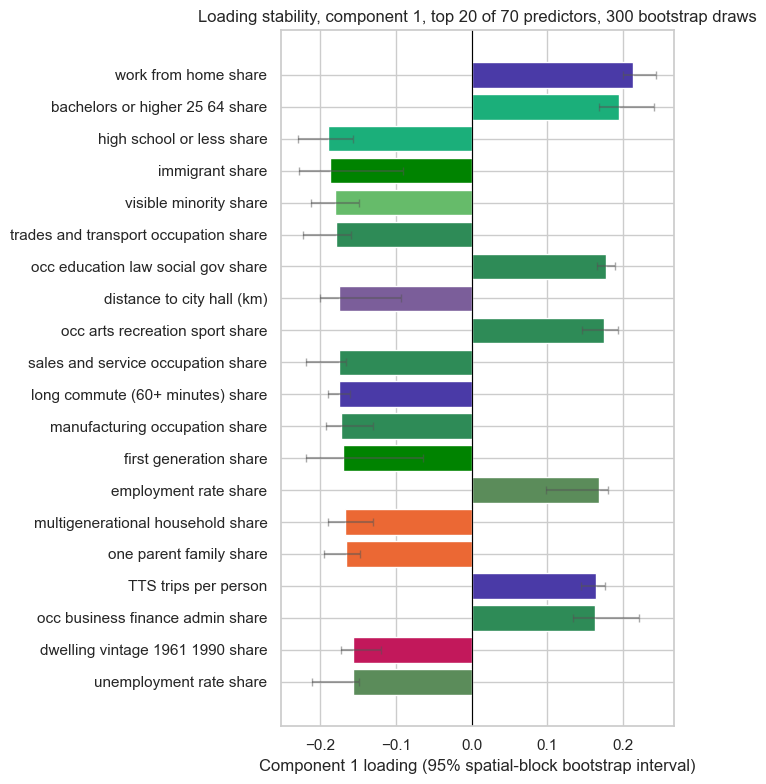

In [18]:
# Loading-stability plot, component 1 -- limited to the top 20 by |loading|
# for legibility now that there are 70 predictors instead of 14.
plot_df = component1.sort_values("abs_full_loading", ascending=False).head(20).sort_values("abs_full_loading")
bar_colors = plot_df["family"].map(FAMILY_COLORS)

fig, ax = plt.subplots(figsize=(7, 0.35 * len(plot_df) + 1))
ax.barh(plot_df["plain_name"], plot_df["full_loading"], xerr=[
    plot_df["full_loading"] - plot_df["lower_95"], plot_df["upper_95"] - plot_df["full_loading"]
], color=bar_colors, ecolor="#55555580", capsize=3)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Component 1 loading (95% spatial-block bootstrap interval)")
ax.set_title(f"Loading stability, component 1, top 20 of {len(PREDICTORS)} predictors, {N_BOOTSTRAP} bootstrap draws")
plt.tight_layout()
plt.show()

**Verdict (loadings/VIP).** The primary anchors of component 1 should show tight intervals and sign stability close to 1.0 — they stay on the same side of the axis almost regardless of which spatial blocks get resampled. Smaller loadings are the ones expected to cross zero or flip sign across draws. Read the *overall* share of stable (component, variable) pairs as a summary number, but lean on the per-variable table (and the top-20 plot) for which specific predictors the headline story can actually rest its weight on.

### Sparse-PLS selection frequency across bootstrap draws

New in this version: for each predictor and component, what fraction of the 300 bootstrap draws selected it (nonzero weight after soft-thresholding at the already-tuned `sparse_lam`)? A predictor selected in nearly every draw is a robust part of that axis's variable-selection story; one selected only sporadically was likely included in the full-sample fit somewhat by chance. Saved as a sibling file to `robustness_bootstrap_stability_summary.csv` rather than merged into it, since the two tables summarize different estimators (plain PLS loadings/VIP vs. sparse-PLS selection) at a different granularity.

In [19]:
sparse_freq_rows = []
for comp in range(best_n_components):
    for j, variable in enumerate(PREDICTORS):
        sparse_freq_rows.append({
            "component": comp + 1,
            "variable": variable,
            "plain_name": plain_name(variable),
            "family": variable_family(variable),
            "full_sample_selected": bool(full_sparse_selected[j, comp]),
            "bootstrap_selection_frequency": float(sparse_selected_draws[:, j, comp].mean()),
        })
sparse_bootstrap_freq = pd.DataFrame(sparse_freq_rows)
sparse_bootstrap_freq.to_csv(OUTPUT_ROOT / "robustness_bootstrap_sparse_pls_selection_frequency.csv", index=False)

print("Degenerate-component fallback count across the 300 bootstrap draws, by component:")
for comp in range(best_n_components):
    print(f"  component {comp + 1}: {sparse_degenerate_counts[comp]} of {N_BOOTSTRAP} draws")
print()

print("Predictors selected in >=90% of bootstrap draws, by component (the most robustly-selected variables):")
for comp in range(1, best_n_components + 1):
    robust = sparse_bootstrap_freq[
        (sparse_bootstrap_freq["component"] == comp) & (sparse_bootstrap_freq["bootstrap_selection_frequency"] >= 0.90)
    ].sort_values("bootstrap_selection_frequency", ascending=False)
    print(f"\ncomponent {comp}: {len(robust)} predictors at >=90% selection frequency")
    for r in robust.itertuples():
        marker = "selected in full sample" if r.full_sample_selected else "NOT selected in full sample"
        print(f"    {r.plain_name:42s} [{family_label(r.family)}]  freq={r.bootstrap_selection_frequency:.2f}  ({marker})")

sparse_bootstrap_freq.sort_values(["component", "bootstrap_selection_frequency"], ascending=[True, False]).head(30)

Degenerate-component fallback count across the 300 bootstrap draws, by component:
  component 1: 0 of 300 draws
  component 2: 0 of 300 draws
  component 3: 0 of 300 draws
  component 4: 0 of 300 draws

Predictors selected in >=90% of bootstrap draws, by component (the most robustly-selected variables):

component 1: 52 predictors at >=90% selection frequency
    age 18 29 share                            [age life stage]  freq=1.00  (selected in full sample)
    multigenerational household share          [household family]  freq=1.00  (selected in full sample)
    one parent family share                    [household family]  freq=1.00  (selected in full sample)
    average household size                     [household family]  freq=1.00  (selected in full sample)
    not in labour force share                  [labour market]  freq=1.00  (selected in full sample)
    bachelors or higher 25 64 share            [education]  freq=1.00  (selected in full sample)
    unemployment rate shar

,component,variable,plain_name,family,full_sample_selected,bootstrap_selection_frequency
0,1,block1_age_18_29_share,age 18 29 share,age_life_stage,True,1.000000
4,1,block1_average_household_size,average household size,household_family,True,1.000000
6,1,block1_one_parent_family_share,one parent family share,household_family,True,1.000000
7,1,block1_multigenerational_household_share,multigenerational household share,household_family,True,1.000000
9,1,block1_never_married_share,never married share,household_family,True,1.000000
10,1,block1_bachelors_or_higher_25_64_share,bachelors or higher 25 64 share,education,True,1.000000
11,1,block1_college_or_trades_25_64_share,college or trades 25 64 share,education,True,1.000000
12,1,block1_high_school_or_less_share,high school or less share,education,True,1.000000
16,1,block1_unemployment_rate_share,unemployment rate share,labour_market,True,1.000000
17,1,block1_not_in_labour_force_share,not in labour force share,labour_market,True,1.000000


**Verdict (sparse-PLS stability).** A predictor flagged `selected in full sample` that *also* shows a high bootstrap selection frequency is doubly robust: it survived shrinkage on the full data and keeps surviving under resampling. A predictor selected in the full sample but with a low bootstrap frequency was likely a borderline, sample-specific inclusion — treat its presence in the headline sparse-PLS table above as fragile. Degenerate-component fallbacks (reported above) should be rare; if any component degenerates on a meaningful share of draws, that component's sparse-PLS story is unreliable at this `lam` and should be read with real caution, not presented as a clean selection result.

## Overall takeaways

Putting the checks together, on the **current 70-variable, 14-family predictor pool**:

- **Plumbing (Check 0):** the hand-rolled NIPALS implementation still agrees with sklearn's reference PLS implementation at 70 predictors — see the PASS/FAIL printed above. This is a necessary, not sufficient, condition for trusting everything that follows, since all of it reuses `fit_pls`.
- **Geographic generalization (Check 1):** spatially blocked CV (both 5-block and 10-block) shows how much of the shuffled-CV performance survives when whole regions, not random CTs, are held out, and whether PLS, PCR, true supervised PCA, or elastic net generalizes best under that stricter test. The 10-block run is a direct sensitivity check on whether that ranking depends on the specific choice of 5 blocks.
- **Election-level generalization (Check 2):** whether the widened model's primary axis is a property of averaging three elections together, or holds up against each one separately.
- **Does widening change the earlier finding, or just refine it (Check 3, centerpiece):** the leading-component score correlation between the prior-round 14-variable model and the current 70-variable model is the single most direct answer to "did adding 56 more variables discover a different story," with the transportation-dropped subset as a second, lighter-weight version of the same question.
- **Which variables survive variable selection, not just contribute some weight (sparse PLS):** a shrinkage-based complement to VIP, tuned by its own inner cross-validation.
- **Resampling stability (Check 4):** whether the loadings, VIP scores, *and* sparse-PLS selections are a property of the particular 585 CTs sampled, or hold up under spatial-block bootstrap resampling.

None of this establishes causality — these remain cross-sectional, ecological, CT-level associations. What this notebook adds beyond notebook 07 is a stress test of *how much to trust* that model's shape, not a new claim about what drives turnout beyond what notebook 07 already reported.

## Superseded ancestors (not re-run)

Two earlier scripts in the archived `modelling/dimension_reduction/` tree fed into the eventual meeting-PLS model but are not ported here as code — they're noted for lineage only, unchanged from the previous version of this notebook:

- **`latent_interpretation/interpret_existing_latents.py`** consumed already-fit PLS artifacts from two earlier, broader model variants (`full_unfiltered_pls`, fit on the entire predictor universe, and `theory_cleaned_pls`, a theory-trimmed but still large set) and wrote interpretation tables/narrative for those runs. It predates both the compact 14-variable "meeting PLS" and the current 70-variable curated model.
- **`restricted_demographic/run_block1_3_restricted_latents.py`** was a follow-up ablation asking what the latent axes look like if only Blocks 1-3 (demographic, housing, immigration/citizenship — no electoral-competitiveness or transportation/access variables) are used. It's a narrower predecessor of the same idea as this notebook's transportation-dropped alternative subset, superseded once the meeting-PLS model (and now the current model) settled on a broader variable set spanning more blocks/families.

Both are earlier waypoints toward the models in notebooks 07 and 08, not independent robustness evidence, so re-running them wouldn't add anything the checks above don't already cover.